# Imports

In [34]:
%pip install pandas seaborn matplotlib imbalanced-learn scikit-learn scikit-optimize xgboost lightgbm catboost

Note: you may need to restart the kernel to use updated packages.


In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns

import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import time

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance
import pickle

# Exploratory Data Analysis

## Dataset reading

In [36]:
file_path = "Loan_default.csv"
df = pd.read_csv(file_path)

In [37]:
selected_features = [
    "Age", "Income", "LoanAmount", "CreditScore",
    "MonthsEmployed", "NumCreditLines", "InterestRate"
]
target = "Default"

In [38]:
print("Dataset loaded successfully. First ten rows:")
display(df.head(10))

print(f"Dataset shape: {df.shape[0]:,} rows and {df.shape[1]:,} columns.")
print("Dataset structure, data types, and non-null values:")
df.info()

Dataset loaded successfully. First ten rows:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
5,A9S62RQ7US,25,90298,90448,720,18,2,22.72,24,0.10,High School,Unemployed,Single,Yes,No,Business,Yes,1
6,H8GXPAOS71,38,111188,177025,429,80,1,19.11,12,0.16,Bachelor's,Unemployed,Single,Yes,No,Home,Yes,0
7,0HGZQKJ36W,56,126802,155511,531,67,4,8.15,60,0.43,PhD,Full-time,Married,No,No,Home,Yes,0
8,1R0N3LGNRJ,36,42053,92357,827,83,1,23.94,48,0.20,Bachelor's,Self-employed,Divorced,Yes,No,Education,No,1
9,CM9L1GTT2P,40,132784,228510,480,114,4,9.09,48,0.33,High School,Self-employed,Married,Yes,No,Other,Yes,0


Dataset shape: 255,347 rows and 18 columns.
Dataset structure, data types, and non-null values:
<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     2

In [39]:
print("Descriptive statistics for the selected features:")
display(df[selected_features].describe().T)

null_report = pd.DataFrame({
    "Null Count": df[selected_features + [target]].isnull().sum(),
    "Null Percentage": (df[selected_features + [target]].isnull().mean() * 100).round(2)
})
print("Null-value counts and percentages for selected features and target:")
display(null_report)

exact_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicates:,}")

profile_columns = selected_features + [target]
duplicate_profiles = df.duplicated(subset=profile_columns, keep=False).sum()
print(
    f"Rows belonging to duplicated profiles based on the seven selected features "
    f"and {target} (excluding LoanID): {duplicate_profiles:,}"
)

Descriptive statistics for the selected features:


,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0


Null-value counts and percentages for selected features and target:


,Null Count,Null Percentage
Age,0,0.0
Income,0,0.0
LoanAmount,0,0.0
CreditScore,0,0.0
MonthsEmployed,0,0.0
NumCreditLines,0,0.0
InterestRate,0,0.0
Default,0,0.0


Exact duplicate rows: 0
Rows belonging to duplicated profiles based on the seven selected features and Default (excluding LoanID): 0


In [40]:
loan_id_unique = df["LoanID"].is_unique
print(f"LoanID is unique: {loan_id_unique}")

default_distribution = pd.DataFrame({
    "Count": df[target].value_counts(),
    "Proportion (%)": (df[target].value_counts(normalize=True) * 100).round(2)
})
print("Default class counts and proportions:")
display(default_distribution)

LoanID is unique: True
Default class counts and proportions:


,Count,Proportion (%)
Default,,
0,225694,88.39
1,29653,11.61


In [41]:
correlation_matrix = df[selected_features + [target]].corr(numeric_only=True)
print("Correlation matrix for selected numerical features and Default:")
display(correlation_matrix)

correlation_pairs = (
    correlation_matrix.where(
        __import__("numpy").triu(__import__("numpy").ones(correlation_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index(name="Correlation")
    .rename(columns={"level_0": "Feature 1", "level_1": "Feature 2"})
    .sort_values("Correlation", ascending=False)
)

print("Feature correlation pairs sorted in descending order:")
display(correlation_pairs)

Correlation matrix for selected numerical features and Default:


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,Default
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,-0.167783
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.099119
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.086659
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,-0.034166
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.097374
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,0.028330
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.131273
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,1.000000


Feature correlation pairs sorted in descending order:


,Feature 1,Feature 2,Correlation
55,InterestRate,Default,0.131273
23,LoanAmount,Default,0.086659
47,NumCreditLines,Default,0.028330
20,LoanAmount,MonthsEmployed,0.002817
12,Income,MonthsEmployed,0.002675
...,...,...,...
59,Default,CreditScore,NaN
60,Default,MonthsEmployed,NaN
61,Default,NumCreditLines,NaN
62,Default,InterestRate,NaN


# Feature Engineering

In [42]:
from sklearn.base import BaseEstimator, TransformerMixin

EPSILON = 1e-6
MISSING_TOKEN = "__MISSING__"

# Domain assumptions (explicit; not universal truths)
THRESHOLDS = {
    "low_credit_score": 580,          # often used as "poor credit" boundary
    "high_dti": 0.43,                 # common underwriting reference point
    "high_interest_rate": 15.0,       # high annual % borrowing cost (portfolio-specific assumption)
    "low_employment_years": 1.0,      # <1 year considered lower stability
    "high_loan_to_income": 0.40       # annual loan amount >40% of annual income
}

BUCKET_SPECS = {
    "AgeBand": ([18, 25, 35, 45, 55, 65, 120], ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]),
    "CreditScoreBand": ([0, 580, 670, 740, 800, 900], ["Poor", "Fair", "Good", "VeryGood", "Excellent"]),
    "EmploymentDurationBand": ([0, 1, 3, 7, 15, 60], ["<1y", "1-2y", "3-6y", "7-14y", "15y+"]),
    "InterestRateBand": ([0, 5, 10, 15, 25, 100], ["VeryLow", "Low", "Moderate", "High", "VeryHigh"]),
    "DTIRatioBand": ([0, 0.20, 0.35, 0.43, 0.60, 2.0], ["Low", "Moderate", "Elevated", "High", "VeryHigh"]),
    "LoanTermBand": ([0, 12, 24, 36, 60, 120, 600], ["<=12m", "13-24m", "25-36m", "37-60m", "61-120m", "120m+"]),
    "LoanToIncomeBand": ([0, 0.10, 0.20, 0.35, 0.50, 1.0, 10], ["VeryLow", "Low", "Moderate", "High", "VeryHigh", "Extreme"]),
    "PaymentBurdenBand": ([0, 0.10, 0.20, 0.35, 0.50, 1.0, 10], ["VeryLow", "Low", "Moderate", "High", "VeryHigh", "Extreme"])
}


def _safe_divide(numerator, denominator, epsilon=EPSILON):
    denom = np.where(np.abs(denominator) < epsilon, epsilon, denominator)
    return numerator / denom


def _to_binary(series):
    s = series.copy()
    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(0).astype(float).gt(0).astype(int)
    s = s.astype(str).str.strip().str.lower()
    yes_values = {"1", "true", "yes", "y", "t"}
    return s.isin(yes_values).astype(int)


class DeterministicFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, epsilon=EPSILON, missing_token=MISSING_TOKEN):
        self.epsilon = epsilon
        self.missing_token = missing_token
        self.output_columns_ = None

    def fit(self, X, y=None):
        Xt = self._engineer(X.copy())
        self.output_columns_ = Xt.columns.tolist()  # schema only (no learned stats)
        return self

    def transform(self, X):
        Xt = self._engineer(X.copy())
        if self.output_columns_ is not None:
            for c in self.output_columns_:
                if c not in Xt.columns:
                    Xt[c] = np.nan
            Xt = Xt[self.output_columns_]
        return Xt

    def _engineer(self, df_in):
        df = df_in.copy()

        numeric_required = [
            "Age", "Income", "LoanAmount", "CreditScore", "MonthsEmployed",
            "NumCreditLines", "InterestRate", "DTIRatio", "LoanTerm"
        ]
        for col in numeric_required:
            if col not in df.columns:
                df[col] = np.nan
            df[col] = pd.to_numeric(df[col], errors="coerce")

        # 2) Deterministic row-level numerical features
        df["LoanToIncome"] = _safe_divide(df["LoanAmount"], df["Income"], self.epsilon)
        df["IncomePerCreditLine"] = _safe_divide(df["Income"], np.maximum(df["NumCreditLines"], 1), self.epsilon)
        df["LoanPerCreditLine"] = _safe_divide(df["LoanAmount"], np.maximum(df["NumCreditLines"], 1), self.epsilon)
        df["EmploymentYears"] = _safe_divide(df["MonthsEmployed"], 12, self.epsilon)
        df["EmploymentToAgeRatio"] = _safe_divide(
            df["MonthsEmployed"], np.maximum((df["Age"] - 18) * 12, 1), self.epsilon
        )
        df["CreditLinesPerEmploymentYear"] = _safe_divide(
            df["NumCreditLines"], np.maximum(df["EmploymentYears"], 1), self.epsilon
        )
        df["CreditScoreToInterestRatio"] = _safe_divide(
            df["CreditScore"], np.maximum(df["InterestRate"], self.epsilon), self.epsilon
        )
        df["LoanToCreditScore"] = _safe_divide(df["LoanAmount"], np.maximum(df["CreditScore"], 1), self.epsilon)
        df["DebtIncomeProxy"] = df["Income"] * df["DTIRatio"]

        # Amortization assumptions:
        # Income = annual, InterestRate = annual %, LoanTerm = months
        df["MonthlyIncome"] = _safe_divide(df["Income"], 12, self.epsilon)
        df["MonthlyInterestRate"] = _safe_divide(df["InterestRate"], 100 * 12, self.epsilon)

        principal = df["LoanAmount"].to_numpy(dtype=float)
        monthly_rate = df["MonthlyInterestRate"].to_numpy(dtype=float)
        n_months = df["LoanTerm"].to_numpy(dtype=float)

        with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
            pow_term = np.power(1 + monthly_rate, n_months)
            amort_payment = principal * monthly_rate * pow_term / (pow_term - 1)
            zero_rate_payment = principal / n_months
            est_payment = np.where(np.isclose(monthly_rate, 0.0, atol=self.epsilon), zero_rate_payment, amort_payment)
            est_payment = np.where(n_months <= 0, np.nan, est_payment)

        df["EstimatedMonthlyPayment"] = est_payment
        df["PaymentToMonthlyIncome"] = _safe_divide(df["EstimatedMonthlyPayment"], df["MonthlyIncome"], self.epsilon)
        df["TotalRepayment"] = df["EstimatedMonthlyPayment"] * df["LoanTerm"]
        df["TotalInterest"] = df["TotalRepayment"] - df["LoanAmount"]
        df["InterestBurden"] = _safe_divide(df["TotalInterest"], np.maximum(df["Income"], self.epsilon), self.epsilon)

        # Binary indicators
        has_mortgage = _to_binary(df["HasMortgage"]) if "HasMortgage" in df.columns else pd.Series(0, index=df.index)
        has_dependents = _to_binary(df["HasDependents"]) if "HasDependents" in df.columns else pd.Series(0, index=df.index)
        has_cosigner = _to_binary(df["HasCoSigner"]) if "HasCoSigner" in df.columns else pd.Series(0, index=df.index)

        df["LowCreditScoreFlag"] = (df["CreditScore"] < THRESHOLDS["low_credit_score"]).astype(int)
        df["HighDTIFlag"] = (df["DTIRatio"] >= THRESHOLDS["high_dti"]).astype(int)
        df["HighInterestRateFlag"] = (df["InterestRate"] >= THRESHOLDS["high_interest_rate"]).astype(int)
        df["LowEmploymentStabilityFlag"] = (df["EmploymentYears"] < THRESHOLDS["low_employment_years"]).astype(int)
        df["HighLoanToIncomeFlag"] = (df["LoanToIncome"] >= THRESHOLDS["high_loan_to_income"]).astype(int)
        df["MortgageAndDependentsFlag"] = ((has_mortgage == 1) & (has_dependents == 1)).astype(int)
        df["NoCoSignerHighRiskFlag"] = (
            (has_cosigner == 0) & ((df["LowCreditScoreFlag"] == 1) | (df["HighDTIFlag"] == 1))
        ).astype(int)

        # 3) Fixed-domain buckets (explicit boundaries only)
        for feature_name, (bins, labels) in BUCKET_SPECS.items():
            source = {
                "AgeBand": "Age",
                "CreditScoreBand": "CreditScore",
                "EmploymentDurationBand": "EmploymentYears",
                "InterestRateBand": "InterestRate",
                "DTIRatioBand": "DTIRatio",
                "LoanTermBand": "LoanTerm",
                "LoanToIncomeBand": "LoanToIncome",
                "PaymentBurdenBand": "PaymentToMonthlyIncome"
            }[feature_name]
            df[feature_name] = pd.cut(
                df[source],
                bins=bins,
                labels=labels,
                include_lowest=True,
                right=False
            ).astype("category")

        # 4) Compact categorical interactions
        interaction_sources = [
            "Education", "EmploymentType", "MaritalStatus", "HasDependents",
            "HasMortgage", "LoanPurpose", "HasCoSigner",
            "CreditScoreBand", "EmploymentDurationBand"
        ]
        for c in interaction_sources:
            if c not in df.columns:
                df[c] = self.missing_token
            df[c] = df[c].astype(str).fillna(self.missing_token).replace({"nan": self.missing_token})

        df["Education_EmploymentType"] = df["Education"] + " | " + df["EmploymentType"]
        df["MaritalStatus_HasDependents"] = df["MaritalStatus"] + " | " + df["HasDependents"]
        df["HasMortgage_LoanPurpose"] = df["HasMortgage"] + " | " + df["LoanPurpose"]
        df["HasCoSigner_CreditScoreBand"] = df["HasCoSigner"] + " | " + df["CreditScoreBand"]
        df["EmploymentType_EmploymentDurationBand"] = df["EmploymentType"] + " | " + df["EmploymentDurationBand"]

        return df


def build_feature_catalogue():
    entries = [
        # Name, Family, Definition, DType, Expected relation, Assumptions, Leakage concern
        ("LoanToIncome", "Deterministic Ratio", "LoanAmount / Income", "float", "Higher -> higher risk", "Income annual", "None if both known at application"),
        ("IncomePerCreditLine", "Deterministic Ratio", "Income / max(NumCreditLines,1)", "float", "Lower -> higher risk", "NumCreditLines available", "None"),
        ("LoanPerCreditLine", "Deterministic Ratio", "LoanAmount / max(NumCreditLines,1)", "float", "Higher -> higher risk", "NumCreditLines available", "None"),
        ("EmploymentYears", "Deterministic Transform", "MonthsEmployed / 12", "float", "Lower -> higher risk", "MonthsEmployed measured consistently", "None"),
        ("EmploymentToAgeRatio", "Deterministic Ratio", "MonthsEmployed / max((Age-18)*12,1)", "float", "Lower -> higher risk", "Working age starts at 18", "None"),
        ("CreditLinesPerEmploymentYear", "Deterministic Ratio", "NumCreditLines / max(EmploymentYears,1)", "float", "Very high may imply risk", "Stability interpretation", "None"),
        ("CreditScoreToInterestRatio", "Deterministic Ratio", "CreditScore / max(InterestRate,epsilon)", "float", "Lower -> higher risk", "Rate as annual percent", "None"),
        ("LoanToCreditScore", "Deterministic Ratio", "LoanAmount / max(CreditScore,1)", "float", "Higher -> higher risk", "CreditScore positive", "None"),
        ("DebtIncomeProxy", "Deterministic Composite", "Income * DTIRatio", "float", "Higher -> higher risk", "DTI properly scaled", "None"),
        ("MonthlyIncome", "Amortization", "Income / 12", "float", "Lower -> higher risk", "Income annual", "None"),
        ("MonthlyInterestRate", "Amortization", "InterestRate / 100 / 12", "float", "Higher -> higher risk", "InterestRate annual %", "None"),
        ("EstimatedMonthlyPayment", "Amortization", "Standard amortizing-loan formula (zero-rate handled explicitly)", "float", "Higher -> higher risk", "LoanTerm in months", "None"),
        ("PaymentToMonthlyIncome", "Amortization Ratio", "EstimatedMonthlyPayment / MonthlyIncome", "float", "Higher -> higher risk", "Income annual; payment estimate valid", "None"),
        ("TotalRepayment", "Amortization", "EstimatedMonthlyPayment * LoanTerm", "float", "Higher -> potentially higher risk", "LoanTerm in months", "None"),
        ("TotalInterest", "Amortization", "TotalRepayment - LoanAmount", "float", "Higher -> higher risk", "Payment estimate valid", "None"),
        ("InterestBurden", "Amortization Ratio", "TotalInterest / max(Income,epsilon)", "float", "Higher -> higher risk", "Income annual", "None"),
        ("LowCreditScoreFlag", "Binary Flag", f"1 if CreditScore < {THRESHOLDS['low_credit_score']}", "int", "1 -> higher risk", "Threshold is portfolio assumption", "None"),
        ("HighDTIFlag", "Binary Flag", f"1 if DTIRatio >= {THRESHOLDS['high_dti']}", "int", "1 -> higher risk", "Threshold is portfolio assumption", "None"),
        ("HighInterestRateFlag", "Binary Flag", f"1 if InterestRate >= {THRESHOLDS['high_interest_rate']}", "int", "1 -> higher risk", "Threshold is portfolio assumption", "None"),
        ("LowEmploymentStabilityFlag", "Binary Flag", f"1 if EmploymentYears < {THRESHOLDS['low_employment_years']}", "int", "1 -> higher risk", "Threshold is portfolio assumption", "None"),
        ("HighLoanToIncomeFlag", "Binary Flag", f"1 if LoanToIncome >= {THRESHOLDS['high_loan_to_income']}", "int", "1 -> higher risk", "Threshold is portfolio assumption", "None"),
        ("MortgageAndDependentsFlag", "Binary Flag", "1 if HasMortgage==1 and HasDependents==1", "int", "1 -> potentially higher burden", "Household burden proxy", "None"),
        ("NoCoSignerHighRiskFlag", "Binary Flag", "1 if HasCoSigner==0 and (LowCreditScoreFlag==1 or HighDTIFlag==1)", "int", "1 -> higher risk", "Support proxy", "None"),
    ]

    # bucket + interactions metadata
    for b in BUCKET_SPECS:
        entries.append((b, "Fixed Bucket", f"pd.cut with explicit bins for {b}", "category", "Monotonic by band (expected)", "Domain bins only", "None"))
    entries.extend([
        ("Education_EmploymentType", "Categorical Interaction", "Education + ' | ' + EmploymentType", "object", "Segment-dependent", "Missing token injected", "None"),
        ("MaritalStatus_HasDependents", "Categorical Interaction", "MaritalStatus + ' | ' + HasDependents", "object", "Segment-dependent", "Missing token injected", "None"),
        ("HasMortgage_LoanPurpose", "Categorical Interaction", "HasMortgage + ' | ' + LoanPurpose", "object", "Segment-dependent", "Missing token injected", "None"),
        ("HasCoSigner_CreditScoreBand", "Categorical Interaction", "HasCoSigner + ' | ' + CreditScoreBand", "object", "Segment-dependent", "Missing token injected", "None"),
        ("EmploymentType_EmploymentDurationBand", "Categorical Interaction", "EmploymentType + ' | ' + EmploymentDurationBand", "object", "Segment-dependent", "Missing token injected", "None"),
    ])

    return pd.DataFrame(
        entries,
        columns=[
            "Feature name", "Feature family", "Formula or definition", "Data type",
            "Expected risk relationship", "Assumptions", "Potential leakage concern"
        ]
    )


def validate_engineering_output(df_engineered, expected_columns=None, target_col="Default", id_col="LoanID"):
    report = {}

    # No target leakage by naming/usage guard (structural check)
    engineered_cols = [c for c in df_engineered.columns if c not in {target_col, id_col}]
    report["No feature name references target"] = not any(target_col.lower() in c.lower() for c in engineered_cols)

    # LoanID not in modeling input candidates
    report["LoanID absent from modeling inputs"] = id_col not in engineered_cols

    # Null / infinite checks
    num_df = df_engineered.select_dtypes(include=[np.number])
    inf_count = np.isinf(num_df.to_numpy()).sum()
    null_count = df_engineered.isnull().sum().sum()
    report["Infinite numeric values count"] = int(inf_count)
    report["Total null values count"] = int(null_count)

    # Bucket label validity and support
    for b, (_, labels) in BUCKET_SPECS.items():
        if b in df_engineered.columns:
            observed = set(df_engineered[b].dropna().astype(str).unique())
            allowed = set(labels)
            report[f"{b} labels valid"] = observed.issubset(allowed)
            report[f"{b} non-empty support"] = df_engineered[b].notna().sum() > 0

    # Column consistency check (train/valid/test) when expected schema supplied
    if expected_columns is not None:
        report["Schema matches expected columns"] = list(df_engineered.columns) == list(expected_columns)

    # Deterministic guarantee note
    report["No learned medians/means/std/vocab/boundaries"] = True  # design guarantee in this transformer

    return pd.DataFrame(
        {"Validation Check": list(report.keys()), "Result": list(report.values())}
    )


# --- Run on current dataset ---
feature_engineer = DeterministicFeatureEngineer(epsilon=EPSILON, missing_token=MISSING_TOKEN)
df_engineered = feature_engineer.fit_transform(df)

feature_catalogue_df = build_feature_catalogue()
validation_report_df = validate_engineering_output(df_engineered)

print("Engineered dataset shape:", df_engineered.shape)
display(feature_catalogue_df)
display(validation_report_df)

# Optional: keep a modeling-safe column list that excludes target and LoanID
model_input_columns = [c for c in df_engineered.columns if c not in {target, "LoanID"}]
print(f"Model input candidate columns: {len(model_input_columns)}")

Engineered dataset shape: (255347, 54)


,Feature name,Feature family,Formula or definition,Data type,Expected risk relationship,Assumptions,Potential leakage concern
0,LoanToIncome,Deterministic Ratio,LoanAmount / Income,float,Higher -> higher risk,Income annual,None if both known at application
1,IncomePerCreditLine,Deterministic Ratio,"Income / max(NumCreditLines,1)",float,Lower -> higher risk,NumCreditLines available,None
2,LoanPerCreditLine,Deterministic Ratio,"LoanAmount / max(NumCreditLines,1)",float,Higher -> higher risk,NumCreditLines available,None
3,EmploymentYears,Deterministic Transform,MonthsEmployed / 12,float,Lower -> higher risk,MonthsEmployed measured consistently,None
4,EmploymentToAgeRatio,Deterministic Ratio,"MonthsEmployed / max((Age-18)*12,1)",float,Lower -> higher risk,Working age starts at 18,None
5,CreditLinesPerEmploymentYear,Deterministic Ratio,"NumCreditLines / max(EmploymentYears,1)",float,Very high may imply risk,Stability interpretation,None
6,CreditScoreToInterestRatio,Deterministic Ratio,"CreditScore / max(InterestRate,epsilon)",float,Lower -> higher risk,Rate as annual percent,None
7,LoanToCreditScore,Deterministic Ratio,"LoanAmount / max(CreditScore,1)",float,Higher -> higher risk,CreditScore positive,None
8,DebtIncomeProxy,Deterministic Composite,Income * DTIRatio,float,Higher -> higher risk,DTI properly scaled,None
9,MonthlyIncome,Amortization,Income / 12,float,Lower -> higher risk,Income annual,None


,Validation Check,Result
0,No feature name references target,True
1,LoanID absent from modeling inputs,True
2,Infinite numeric values count,0
3,Total null values count,4925
4,AgeBand labels valid,True
5,AgeBand non-empty support,True
6,CreditScoreBand labels valid,True
7,CreditScoreBand non-empty support,True
8,EmploymentDurationBand labels valid,True
9,EmploymentDurationBand non-empty support,True


Model input candidate columns: 52


Top features by absolute correlation with Default:


,Correlation with Default,Absolute Correlation
InterestBurden,0.182979,0.182979
LoanToIncome,0.178963,0.178963
Age,-0.167783,0.167783
PaymentToMonthlyIncome,0.151861,0.151861
MonthlyInterestRate,0.131273,0.131273
InterestRate,0.131273,0.131273
TotalInterest,0.119179,0.119179
HighInterestRateFlag,0.114519,0.114519
TotalRepayment,0.107175,0.107175
CreditScoreToInterestRatio,-0.100765,0.100765


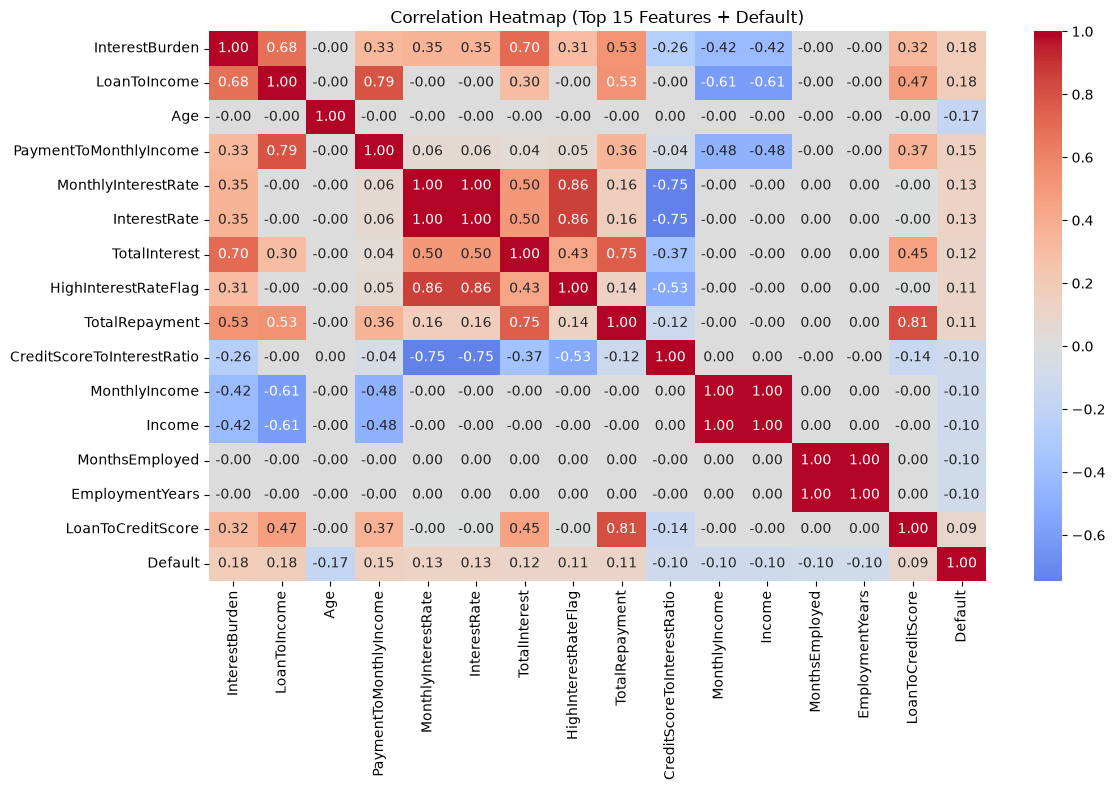

In [43]:
# Correlation analysis (engineered numeric features vs target)
corr_df = df_engineered.drop(columns=["LoanID"], errors="ignore").copy()

# Ensure target is numeric for correlation
corr_df[target] = pd.to_numeric(corr_df[target], errors="coerce")
if corr_df[target].isna().any():
    corr_df[target] = corr_df[target].astype("category").cat.codes

numeric_corr_df = corr_df.select_dtypes(include=[np.number])

# Full numeric correlation matrix
correlation_matrix = numeric_corr_df.corr()

# Rank features by absolute correlation with target
target_correlation = (
    correlation_matrix[target]
    .drop(labels=[target], errors="ignore")
    .sort_values(key=np.abs, ascending=False)
    .to_frame(name="Correlation with Default")
)
target_correlation["Absolute Correlation"] = target_correlation["Correlation with Default"].abs()

print("Top features by absolute correlation with Default:")
display(target_correlation.head(20))

# Heatmap for the most target-correlated features
top_n = 15
top_features = target_correlation.head(top_n).index.tolist()
heatmap_cols = top_features + [target]

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_corr_df[heatmap_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title(f"Correlation Heatmap (Top {top_n} Features + {target})")
plt.tight_layout()
plt.show()

In [44]:
corr_threshold = 0.10

selected_corr_features = target_correlation[
    target_correlation["Correlation with Default"] >= corr_threshold
].index.tolist()

print(f"Features with Correlation with Default >= {corr_threshold}:")
print(selected_corr_features)

# Optional: subset engineered data with selected features (+ target)
df_selected_corr = df_engineered[selected_corr_features + [target]].copy()
display(df_selected_corr.head())

Features with Correlation with Default >= 0.1:
['InterestBurden', 'LoanToIncome', 'PaymentToMonthlyIncome', 'MonthlyInterestRate', 'InterestRate', 'TotalInterest', 'HighInterestRateFlag', 'TotalRepayment']


,InterestBurden,LoanToIncome,PaymentToMonthlyIncome,MonthlyInterestRate,InterestRate,TotalInterest,HighInterestRateFlag,TotalRepayment,Default
0,0.148248,0.588262,0.245503,0.012692,15.23,12748.449617,1,63335.449617,0
1,0.313515,2.467481,0.556199,0.004008,4.81,15811.172745,0,140251.172745,0
2,0.360926,1.534154,0.947540,0.017642,21.17,30392.839547,1,159580.839547,1
3,0.106377,1.412638,0.759508,0.005892,7.07,3373.529264,0,48172.529264,0
4,0.061952,0.447179,0.127283,0.005425,6.51,1266.109178,0,10405.109178,0


Correlation of selected features with target:


,Correlation with Default,Absolute Correlation
InterestBurden,0.182979,0.182979
LoanToIncome,0.178963,0.178963
Age,-0.167783,0.167783
PaymentToMonthlyIncome,0.151861,0.151861
MonthlyInterestRate,0.131273,0.131273
InterestRate,0.131273,0.131273
TotalInterest,0.119179,0.119179
HighInterestRateFlag,0.114519,0.114519
TotalRepayment,0.107175,0.107175
CreditScoreToInterestRatio,-0.100765,0.100765


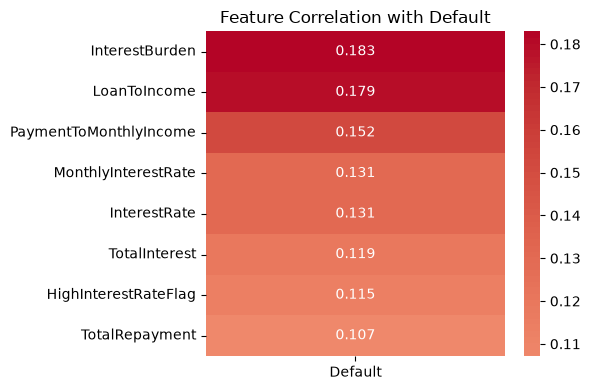

In [45]:
# Correlation matrix for the chosen features + target
# Uses `top_features` from previous cells (falls back to `selected_features` if needed)
features_to_check = selected_corr_features 

corr_subset = df_engineered[features_to_check + [target]].corr(numeric_only=True)

print("Correlation of selected features with target:")
features_to_check = target_correlation.index[
    target_correlation["Absolute Correlation"] >= 0.10
].tolist()

display(
    target_correlation.loc[features_to_check]
    .sort_values(by="Absolute Correlation", ascending=False)
)

plt.figure(figsize=(6, max(4, len(features_to_check) * 0.35)))
sns.heatmap(
    corr_subset[[target]].drop(index=target),
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)
plt.title(f"Feature Correlation with {target}")
plt.tight_layout()
plt.show()

In [46]:
selected_features = selected_corr_features
df = df_engineered[selected_features + [target]].copy()

In [47]:
X = df[selected_features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [48]:
target_distributions = pd.DataFrame({
    "Full dataset": y.value_counts(normalize=True).mul(100).round(2),
    "Training set": y_train.value_counts(normalize=True).mul(100).round(2),
    "Test set": y_test.value_counts(normalize=True).mul(100).round(2)
})

target_counts = pd.DataFrame({
    "Full dataset": y.value_counts(),
    "Training set": y_train.value_counts(),
    "Test set": y_test.value_counts()
})

display(target_counts)
display(target_distributions)

,Full dataset,Training set,Test set
Default,,,
0,225694,180555,45139
1,29653,23722,5931


,Full dataset,Training set,Test set
Default,,,
0,88.39,88.39,88.39
1,11.61,11.61,11.61


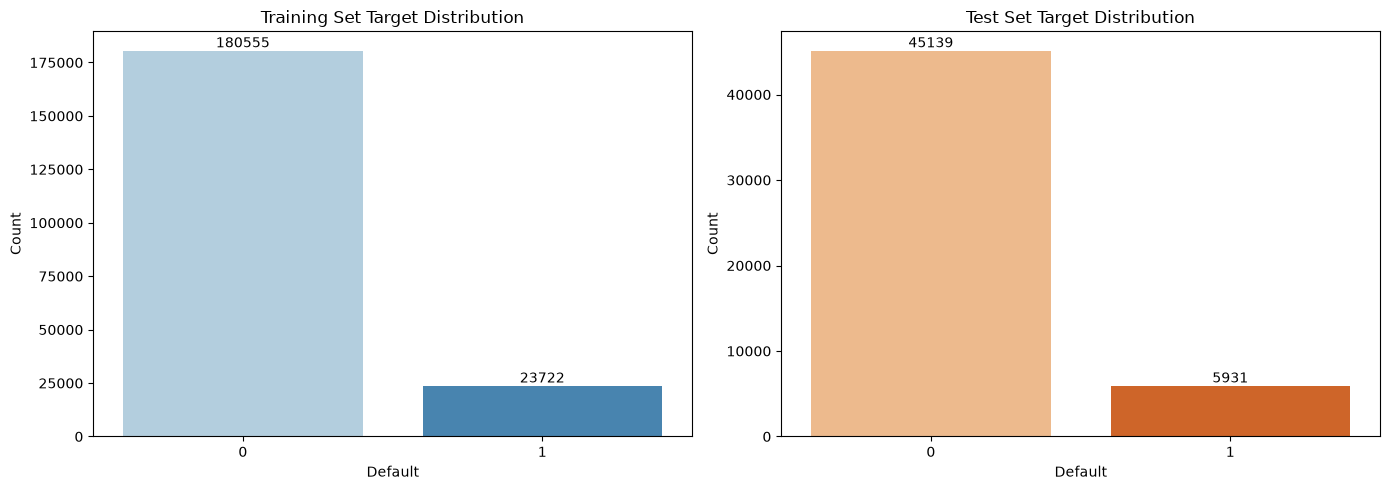

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=y_train, ax=axes[0], hue=y_train, palette="Blues", legend=False)
axes[0].set_title("Training Set Target Distribution")
axes[0].set_xlabel("Default")
axes[0].set_ylabel("Count")

sns.countplot(x=y_test, ax=axes[1], hue=y_test, palette="Oranges", legend=False)
axes[1].set_title("Test Set Target Distribution")
axes[1].set_xlabel("Default")
axes[1].set_ylabel("Count")

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

# Model Development

In [50]:
print("=" * 90)
print("CROSS-VALIDATED MODEL DEVELOPMENT")
print("=" * 90)
print("Pipeline order: StandardScaler → SMOTE(sampling_strategy=0.5) → Model")
print("GridSearchCV receives the original X_train and y_train only.")
print("Scoring metric: Average Precision (PR-AUC)")
print("Cross-validation: StratifiedKFold(n_splits=3, shuffle=True, random_state=42)")
print("=" * 90)

CROSS-VALIDATED MODEL DEVELOPMENT
Pipeline order: StandardScaler → SMOTE(sampling_strategy=0.5) → Model
GridSearchCV receives the original X_train and y_train only.
Scoring metric: Average Precision (PR-AUC)
Cross-validation: StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


In [51]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [52]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

models_and_spaces = [
    (
        "Logistic Regression",
        LogisticRegression(random_state=42, max_iter=1000, n_jobs=1),
        {
            "model__C": Real(1e-2, 10.0, prior="log-uniform"),
            "model__penalty": Categorical(["l1", "l2"]),
            "model__solver": Categorical(["saga"]),
        },
    ),
    (
        "SVM",
        LinearSVC(random_state=42, max_iter=2000),
        {
            "model__C": Real(1e-2, 10.0, prior="log-uniform"),
            "model__penalty": Categorical(["l2"]),
            "model__loss": Categorical(["squared_hinge"]),
        },
    ),
    (
        "CatBoost",
        CatBoostClassifier(
            random_state=42,
            thread_count=1,
            verbose=0,
            allow_writing_files=False,
        ),
        {
            "model__iterations": Integer(100, 600),
            "model__learning_rate": Real(0.01, 0.2, prior="log-uniform"),
            "model__depth": Integer(3, 8),
        },
    ),
    (
        "AdaBoost",
        AdaBoostClassifier(random_state=42),
        {
            "model__n_estimators": Integer(50, 300),
            "model__learning_rate": Real(0.01, 1.0, prior="log-uniform"),
        },
    ),
    (
        "LightGBM",
        LGBMClassifier(random_state=42, n_jobs=1, verbosity=-1),
        {
            "model__n_estimators": Integer(100, 600),
            "model__learning_rate": Real(0.01, 0.2, prior="log-uniform"),
            "model__num_leaves": Integer(16, 128),
        },
    ),
    (
        "XGBoost",
        XGBClassifier(
            random_state=42,
            n_jobs=1,
            eval_metric="logloss",
            tree_method="hist",
        ),
        {
            "model__n_estimators": Integer(100, 600),
            "model__learning_rate": Real(0.01, 0.2, prior="log-uniform"),
            "model__max_depth": Integer(3, 8),
        },
    ),
    (
        "Random Forest (Balanced Focus)",
        RandomForestClassifier(random_state=42, n_jobs=1, class_weight="balanced_subsample"),
        {
            "model__n_estimators": Integer(100, 700),
            "model__max_depth": Integer(4, 16),
            "model__min_samples_leaf": Integer(1, 5),
        },
    ),
    (
        "Random Forest",
        RandomForestClassifier(random_state=42, n_jobs=1),
        {
            "model__n_estimators": Integer(100, 700),
            "model__max_depth": Integer(4, 16),
            "model__min_samples_leaf": Integer(1, 5),
        },
    ),
]

results = []
best_models = {}
n_iter = 25

for model_name, model, search_space in models_and_spaces:
    print(f"\n{'─' * 90}")
    print(f"Training: {model_name}")
    print(f"Bayesian optimization iterations: {n_iter}")
    print("Running 3-fold stratified BayesSearchCV...")

    pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),
        ("model", model)
    ])

    bayes_search = BayesSearchCV(
        estimator=pipeline,
        search_spaces=search_space,
        n_iter=n_iter,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=False,
        random_state=42
    )

    start_time = time.perf_counter()
    bayes_search.fit(X_train, y_train)
    training_time = time.perf_counter() - start_time

    best_model = bayes_search.best_estimator_
    best_models[model_name] = best_model

    y_pred = best_model.predict(X_test)

    if hasattr(best_model, "predict_proba"):
        y_score = best_model.predict_proba(X_test)[:, 1]
    else:
        y_score = best_model.decision_function(X_test)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    test_pr_auc = average_precision_score(y_test, y_score)
    test_roc_auc = roc_auc_score(y_test, y_score)

    best_cv_std = bayes_search.cv_results_["std_test_score"][bayes_search.best_index_]

    print(f"Best hyperparameters: {bayes_search.best_params_}")
    print(f"Best CV PR-AUC:      {bayes_search.best_score_:.4f} ± {best_cv_std:.4f}")
    print(f"Training time:       {training_time:.2f} seconds")
    print(f"Test Precision:      {precision:.4f}")
    print(f"Test Recall:         {recall:.4f}")
    print(f"Test F1-Score:       {f1:.4f}")
    print(f"Test PR-AUC:         {test_pr_auc:.4f}")
    print(f"Test ROC-AUC:        {test_roc_auc:.4f}")

    results.append({
        "Model": model_name,
        "Best Hyperparameters": bayes_search.best_params_,
        "CV PR-AUC": bayes_search.best_score_,
        "CV PR-AUC Std": best_cv_std,
        "Training Time (sec)": training_time,
        "Test Precision": precision,
        "Test Recall": recall,
        "Test F1-Score": f1,
        "Test PR-AUC": test_pr_auc,
        "Test ROC-AUC": test_roc_auc
    })



──────────────────────────────────────────────────────────────────────────────────────────
Training: Logistic Regression
Bayesian optimization iterations: 25
Running 3-fold stratified BayesSearchCV...


c:\Users\jorge\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\jorge\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\jorge\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Best hyperparameters: OrderedDict({'model__C': 0.014372532222897003, 'model__penalty': 'l1', 'model__solver': 'saga'})
Best CV PR-AUC:      0.2378 ± 0.0054
Training time:       44.59 seconds
Test Precision:      0.3070
Test Recall:         0.2040
Test F1-Score:       0.2451
Test PR-AUC:         0.2413
Test ROC-AUC:        0.6736

──────────────────────────────────────────────────────────────────────────────────────────
Training: SVM
Bayesian optimization iterations: 25
Running 3-fold stratified BayesSearchCV...
Best hyperparameters: OrderedDict({'model__C': 0.7099668574083867, 'model__loss': 'squared_hinge', 'model__penalty': 'l2'})
Best CV PR-AUC:      0.2378 ± 0.0054
Training time:       17.38 seconds
Test Precision:      0.3141
Test Recall:         0.1932
Test F1-Score:       0.2392
Test PR-AUC:         0.2415
Test ROC-AUC:        0.6736

──────────────────────────────────────────────────────────────────────────────────────────
Training: CatBoost
Bayesian optimization iterations: 25

In [53]:
results_df = (
    pd.DataFrame(results)
    .sort_values("Test PR-AUC", ascending=False)
    .reset_index(drop=True)
)

print(f"\n{'=' * 90}")
print("FINAL MODEL COMPARISON — SORTED BY TEST PR-AUC")
print(f"{'=' * 90}")

print(
    results_df.to_string(
        index=False,
        formatters={
            "CV PR-AUC": "{:.4f}".format,
            "CV PR-AUC Std": "{:.4f}".format,
            "Training Time (sec)": "{:.2f}".format,
            "Test Precision": "{:.4f}".format,
            "Test Recall": "{:.4f}".format,
            "Test F1-Score": "{:.4f}".format,
            "Test PR-AUC": "{:.4f}".format,
            "Test ROC-AUC": "{:.4f}".format
        }
    )
)

print(f"\nBest model by Test PR-AUC: {results_df.loc[0, 'Model']}")
print(f"Best Test PR-AUC: {results_df.loc[0, 'Test PR-AUC']:.4f}")


FINAL MODEL COMPARISON — SORTED BY TEST PR-AUC
                         Model                                                                                Best Hyperparameters CV PR-AUC CV PR-AUC Std Training Time (sec) Test Precision Test Recall Test F1-Score Test PR-AUC Test ROC-AUC
                           SVM            {'model__C': 0.7099668574083867, 'model__loss': 'squared_hinge', 'model__penalty': 'l2'}    0.2378        0.0054               17.38         0.3141      0.1932        0.2392      0.2415       0.6736
           Logistic Regression                 {'model__C': 0.014372532222897003, 'model__penalty': 'l1', 'model__solver': 'saga'}    0.2378        0.0054               44.59         0.3070      0.2040        0.2451      0.2413       0.6736
                 Random Forest                   {'model__max_depth': 6, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}    0.2350        0.0060             2046.10         0.2995      0.2099        0.2468      0.2410  

In [54]:
print(f"\n{'=' * 90}")
print("FINAL MODEL COMPARISON — SORTED BY TEST PR-AUC")
print(f"{'=' * 90}")

print(
    results_df.to_string(
        index=False,
        formatters={
            "CV PR-AUC": "{:.4f}".format,
            "CV PR-AUC Std": "{:.4f}".format,
            "Training Time (sec)": "{:.2f}".format,
            "Test Precision": "{:.4f}".format,
            "Test Recall": "{:.4f}".format,
            "Test F1-Score": "{:.4f}".format,
            "Test PR-AUC": "{:.4f}".format,
            "Test ROC-AUC": "{:.4f}".format
        }
    )
)

print(f"\nBest model by Test PR-AUC: {results_df.loc[0, 'Model']}")
print(f"Best Test PR-AUC: {results_df.loc[0, 'Test PR-AUC']:.4f}")


FINAL MODEL COMPARISON — SORTED BY TEST PR-AUC
                         Model                                                                                Best Hyperparameters CV PR-AUC CV PR-AUC Std Training Time (sec) Test Precision Test Recall Test F1-Score Test PR-AUC Test ROC-AUC
                           SVM            {'model__C': 0.7099668574083867, 'model__loss': 'squared_hinge', 'model__penalty': 'l2'}    0.2378        0.0054               17.38         0.3141      0.1932        0.2392      0.2415       0.6736
           Logistic Regression                 {'model__C': 0.014372532222897003, 'model__penalty': 'l1', 'model__solver': 'saga'}    0.2378        0.0054               44.59         0.3070      0.2040        0.2451      0.2413       0.6736
                 Random Forest                   {'model__max_depth': 6, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}    0.2350        0.0060             2046.10         0.2995      0.2099        0.2468      0.2410  

In [55]:
k_values = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
test_default_rate = y_test.mean()

evaluation_results = []
ranking_curves = []
permutation_results = []

for model_name, fitted_pipeline in best_models.items():
    if hasattr(fitted_pipeline, "predict_proba"):
        scores = fitted_pipeline.predict_proba(X_test)[:, 1]
    else:
        scores = fitted_pipeline.decision_function(X_test)

    predictions = fitted_pipeline.predict(X_test)

    model_metrics = {
        "Model": model_name,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-Score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, scores),
        "PR-AUC": average_precision_score(y_test, scores),
        "Predicted Positive Rate": predictions.mean()
    }

    print(f"\n{'=' * 70}\n{model_name}")
    print(f"Precision: {model_metrics['Precision']:.4f}")
    print(f"Recall:    {model_metrics['Recall']:.4f}")
    print(f"F1-Score:  {model_metrics['F1-Score']:.4f}")
    print(f"ROC-AUC:   {model_metrics['ROC-AUC']:.4f}")
    print(f"PR-AUC:    {model_metrics['PR-AUC']:.4f}")

    ranked_indices = np.argsort(-scores)

    for k in k_values:
        top_n = int(np.ceil(len(y_test) * k))
        top_k_actuals = y_test.iloc[ranked_indices[:top_n]]

        precision_at_k = top_k_actuals.mean()
        recall_at_k = top_k_actuals.sum() / y_test.sum()
        lift_at_k = precision_at_k / test_default_rate

        label = f"{int(k * 100)}%"
        model_metrics[f"Precision@{label}"] = precision_at_k
        model_metrics[f"Recall@{label}"] = recall_at_k
        model_metrics[f"Lift@{label}"] = lift_at_k

        ranking_curves.append({
            "Model": model_name,
            "Top Population (%)": int(k * 100),
            "Precision@k": precision_at_k,
            "Recall@k": recall_at_k,
            "Lift@k": lift_at_k
        })

    evaluation_results.append(model_metrics)

    print("Calculating permutation importance...")
    permutation = permutation_importance(
        fitted_pipeline,
        X_test,
        y_test,
        scoring="average_precision",
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    permutation_results.append(
        pd.DataFrame({
            "Model": model_name,
            "Feature": selected_features,
            "Importance Mean": permutation.importances_mean,
            "Importance Std": permutation.importances_std
        })
    )


Logistic Regression
Precision: 0.3070
Recall:    0.2040
F1-Score:  0.2451
ROC-AUC:   0.6736
PR-AUC:    0.2413
Calculating permutation importance...

SVM
Precision: 0.3141
Recall:    0.1932
F1-Score:  0.2392
ROC-AUC:   0.6736
PR-AUC:    0.2415
Calculating permutation importance...

CatBoost
Precision: 0.3064
Recall:    0.2011
F1-Score:  0.2429
ROC-AUC:   0.6719
PR-AUC:    0.2403
Calculating permutation importance...

AdaBoost
Precision: 0.3210
Recall:    0.1836
F1-Score:  0.2336
ROC-AUC:   0.6699
PR-AUC:    0.2382
Calculating permutation importance...

LightGBM
Precision: 0.3252
Recall:    0.1841
F1-Score:  0.2351
ROC-AUC:   0.6712
PR-AUC:    0.2399
Calculating permutation importance...

XGBoost
Precision: 0.2947
Recall:    0.2077
F1-Score:  0.2437
ROC-AUC:   0.6709
PR-AUC:    0.2394
Calculating permutation importance...

Random Forest (Balanced Focus)
Precision: 0.1778
Recall:    0.5972
F1-Score:  0.2741
ROC-AUC:   0.6712
PR-AUC:    0.2406
Calculating permutation importance...

Random

In [56]:
evaluation_df = (
    pd.DataFrame(evaluation_results)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

model_selection_df = (
    results_df[
        ["Model", "Best Hyperparameters", "CV PR-AUC", "CV PR-AUC Std", "Training Time (sec)", "Test PR-AUC", "Test ROC-AUC"]
    ].copy()
)

model_selection_df["CV-to-Test PR-AUC Difference"] = (
    model_selection_df["CV PR-AUC"] - model_selection_df["Test PR-AUC"]
)

permutation_importance_df = pd.concat(permutation_results, ignore_index=True)
ranking_curves_df = pd.DataFrame(ranking_curves)

print("\nMASTER EVALUATION RESULTS")
display(evaluation_df)

print("\nBEST PARAMETERS AND CV RESULTS")
display(model_selection_df.sort_values("Test PR-AUC", ascending=False))

# Grouped bar chart of core metrics
core_metrics = ["Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]
plot_metrics = evaluation_df.set_index("Model")[core_metrics]



MASTER EVALUATION RESULTS


,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Predicted Positive Rate,Precision@5%,Recall@5%,Lift@5%,...,Lift@15%,Precision@20%,Recall@20%,Lift@20%,Precision@25%,Recall@25%,Lift@25%,Precision@30%,Recall@30%,Lift@30%
0,SVM,0.314059,0.193222,0.239248,0.673626,0.241452,0.071451,0.352780,0.151914,3.037679,...,2.146772,0.226356,0.389816,1.949081,0.210448,0.453043,1.812102,0.197311,0.509695,1.698983
1,Logistic Regression,0.307029,0.204013,0.245138,0.673643,0.241336,0.077169,0.354346,0.152588,3.051164,...,2.133284,0.227237,0.391334,1.956668,0.211466,0.455235,1.820870,0.197572,0.510369,1.701231
2,Random Forest,0.299495,0.209914,0.246828,0.671348,0.240999,0.081398,0.355912,0.153263,3.064650,...,2.128788,0.225866,0.388973,1.944866,0.212093,0.456584,1.826265,0.197702,0.510706,1.702355
3,Random Forest (Balanced Focus),0.177847,0.597201,0.274074,0.671183,0.240579,0.389975,0.354346,0.152588,3.051164,...,2.143400,0.226258,0.389648,1.948238,0.211466,0.455235,1.820870,0.197637,0.510538,1.701793
4,CatBoost,0.306447,0.201147,0.242875,0.671894,0.240271,0.076229,0.351214,0.151239,3.024193,...,2.126540,0.225377,0.388130,1.940651,0.211623,0.455572,1.822218,0.196267,0.506997,1.689990
5,LightGBM,0.325194,0.184117,0.235117,0.671217,0.239922,0.065753,0.350431,0.150902,3.017450,...,2.113053,0.226258,0.389648,1.948238,0.210526,0.453212,1.812777,0.196658,0.508009,1.693363
6,XGBoost,0.294666,0.207722,0.243671,0.670900,0.239405,0.081868,0.351997,0.151576,3.030936,...,2.108557,0.226160,0.389479,1.947395,0.210213,0.452538,1.810079,0.197507,0.510201,1.700669
7,AdaBoost,0.320955,0.183612,0.233591,0.669914,0.238213,0.066438,0.353563,0.152251,3.044422,...,2.110805,0.223419,0.384758,1.923790,0.208490,0.448828,1.795242,0.195875,0.505985,1.686618



BEST PARAMETERS AND CV RESULTS


,Model,Best Hyperparameters,CV PR-AUC,CV PR-AUC Std,Training Time (sec),Test PR-AUC,Test ROC-AUC,CV-to-Test PR-AUC Difference
0,SVM,"{'model__C': 0.7099668574083867, 'model__loss'...",0.237803,0.005395,17.383058,0.241452,0.673626,-0.003649
1,Logistic Regression,"{'model__C': 0.014372532222897003, 'model__pen...",0.237794,0.005371,44.593331,0.241336,0.673643,-0.003542
2,Random Forest,"{'model__max_depth': 6, 'model__min_samples_le...",0.234967,0.006003,2046.101353,0.240999,0.671348,-0.006032
3,Random Forest (Balanced Focus),"{'model__max_depth': 6, 'model__min_samples_le...",0.234105,0.005344,2285.348793,0.240579,0.671183,-0.006474
4,CatBoost,"{'model__depth': 3, 'model__iterations': 593, ...",0.236208,0.004975,340.032400,0.240271,0.671894,-0.004063
5,LightGBM,"{'model__learning_rate': 0.023021035605794337,...",0.235601,0.006177,104.950976,0.239922,0.671217,-0.004321
6,XGBoost,"{'model__learning_rate': 0.01, 'model__max_dep...",0.235107,0.005552,96.114030,0.239405,0.670900,-0.004298
7,AdaBoost,"{'model__learning_rate': 0.16864153233640153, ...",0.234294,0.005204,971.593857,0.238213,0.669914,-0.003918


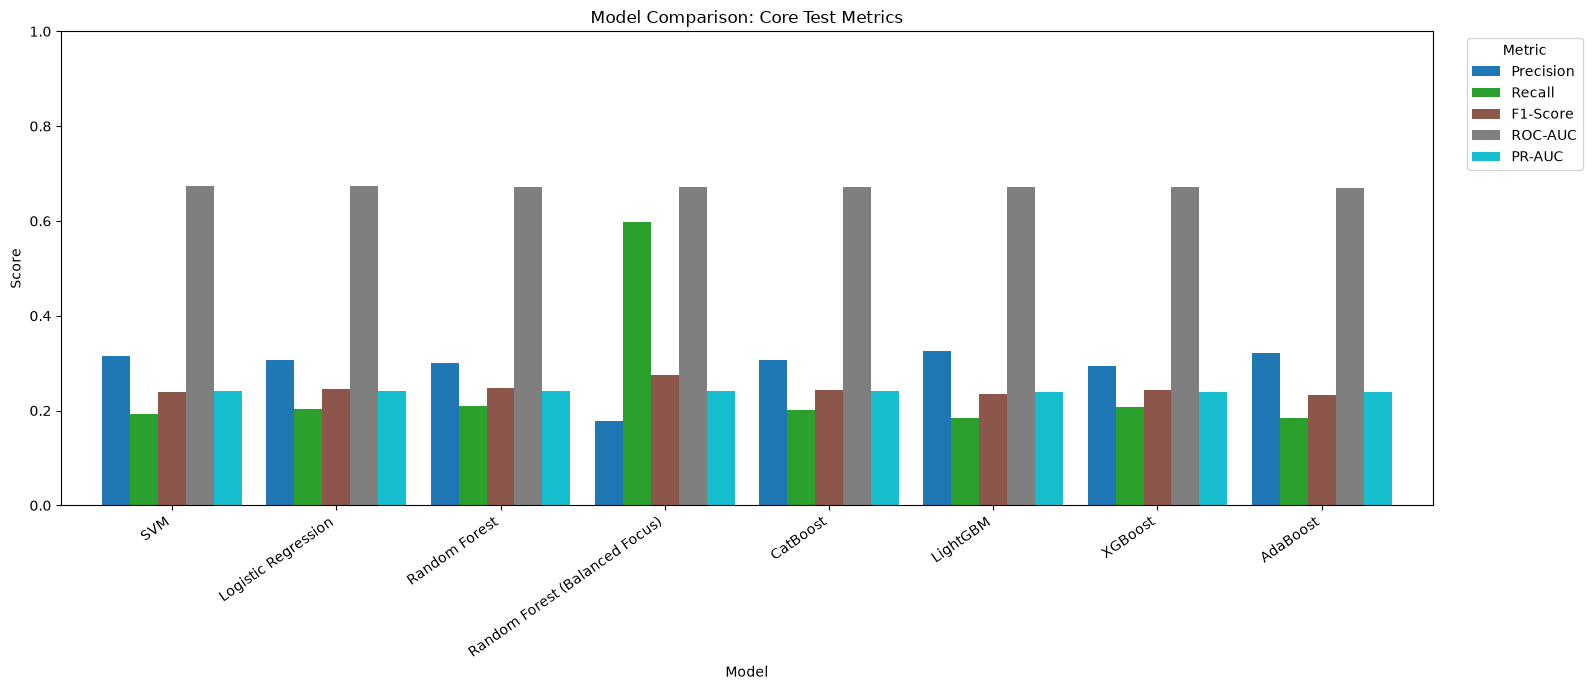

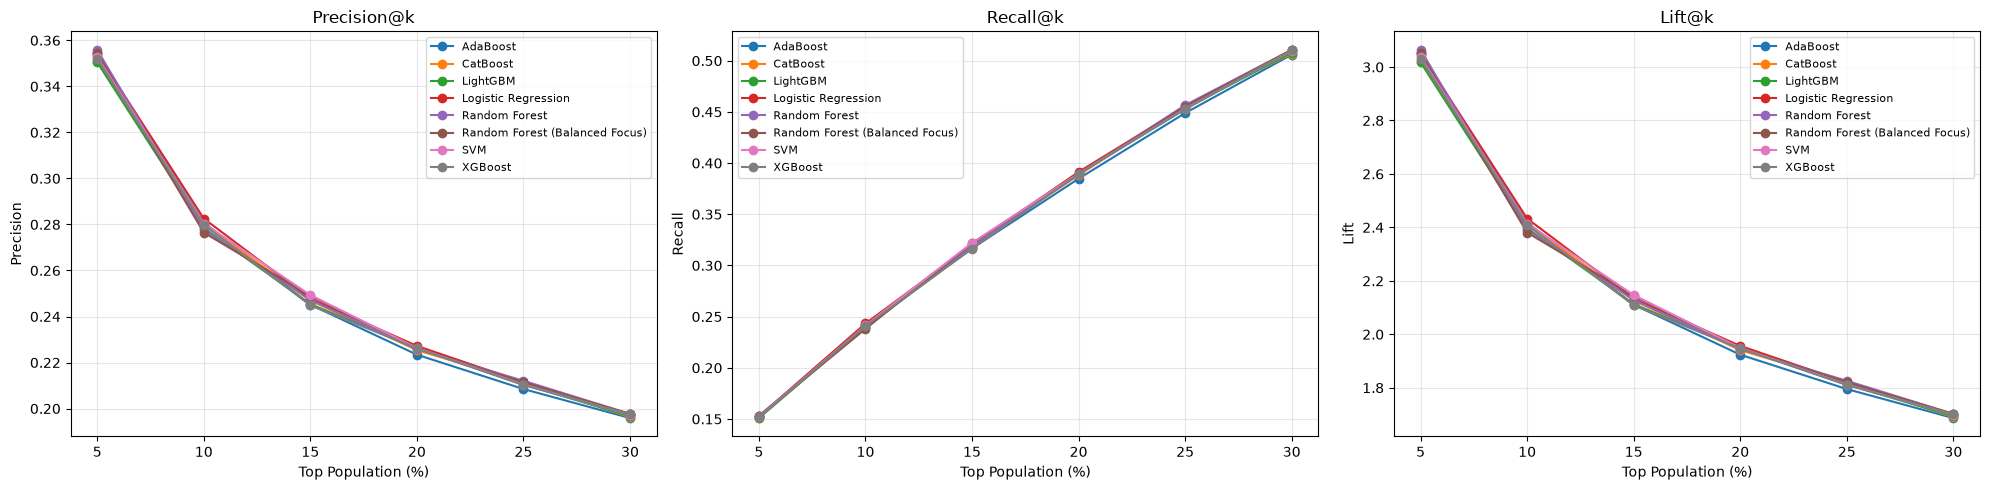

In [57]:

ax = plot_metrics.plot(
    kind="bar",
    figsize=(16, 7),
    width=0.85,
    colormap="tab10"
)
ax.set_title("Model Comparison: Core Test Metrics")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_ylim(0, 1)
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Ranking performance curves
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for model_name, group in ranking_curves_df.groupby("Model"):
    group = group.sort_values("Top Population (%)")
    axes[0].plot(group["Top Population (%)"], group["Precision@k"], marker="o", label=model_name)
    axes[1].plot(group["Top Population (%)"], group["Recall@k"], marker="o", label=model_name)
    axes[2].plot(group["Top Population (%)"], group["Lift@k"], marker="o", label=model_name)

axes[0].set_title("Precision@k")
axes[1].set_title("Recall@k")
axes[2].set_title("Lift@k")

for axis in axes:
    axis.set_xlabel("Top Population (%)")
    axis.grid(alpha=0.3)
    axis.legend(fontsize=8)

axes[0].set_ylabel("Precision")
axes[1].set_ylabel("Recall")
axes[2].set_ylabel("Lift")

plt.tight_layout()
plt.show()

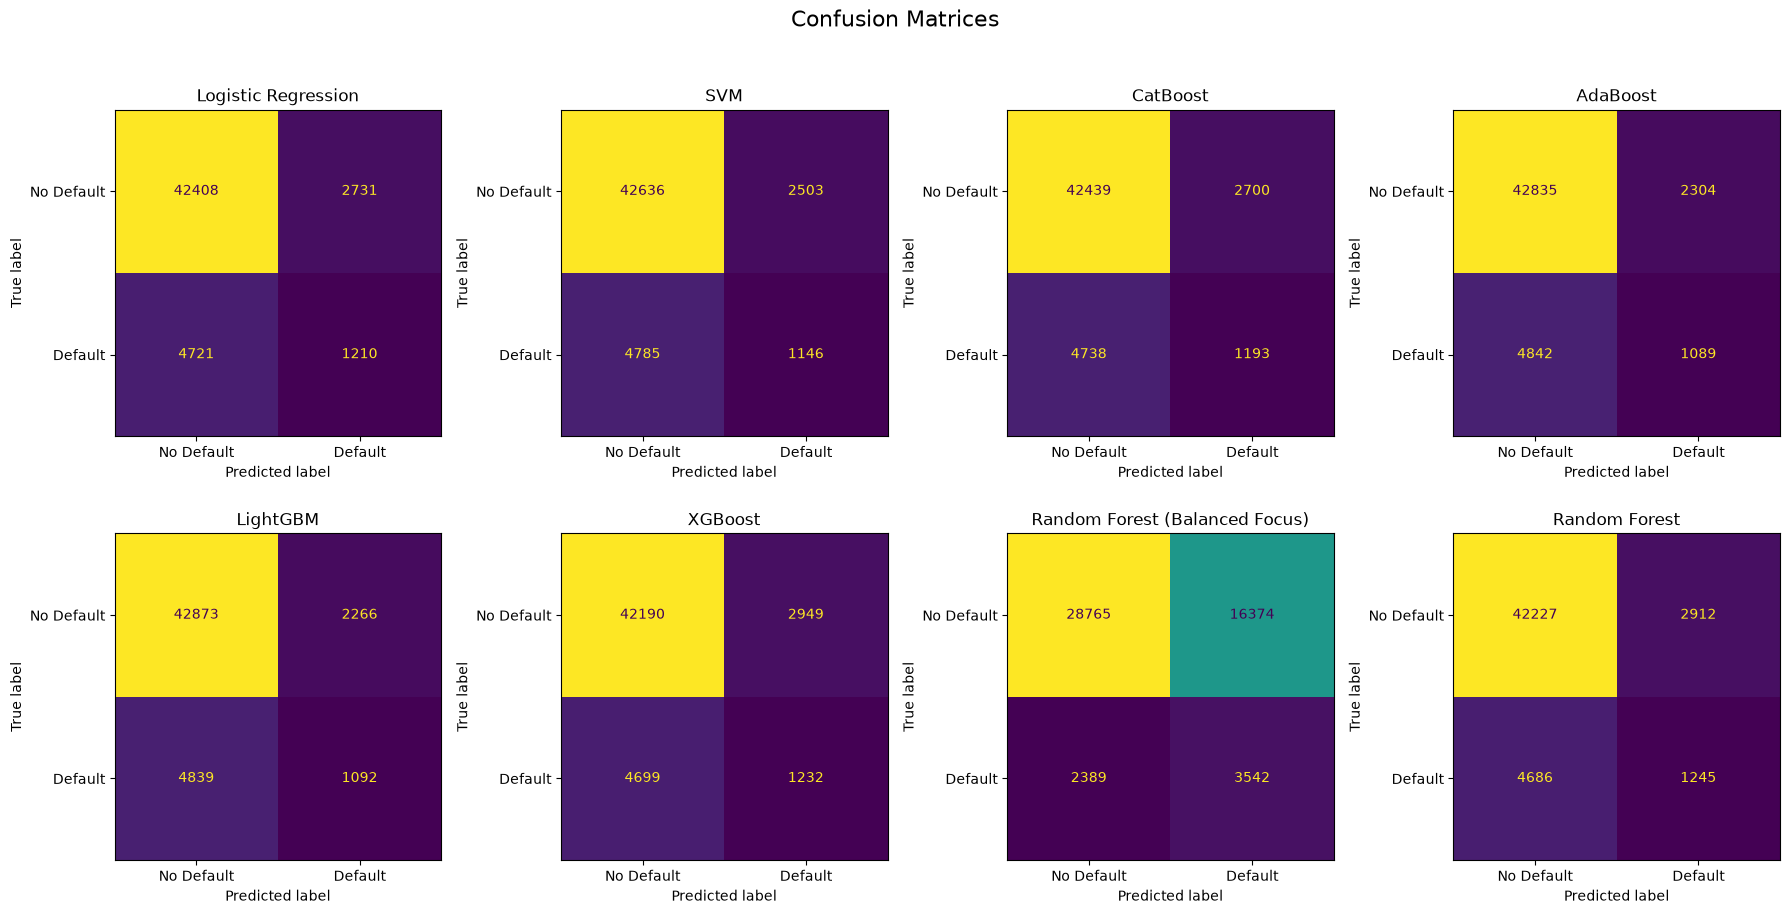

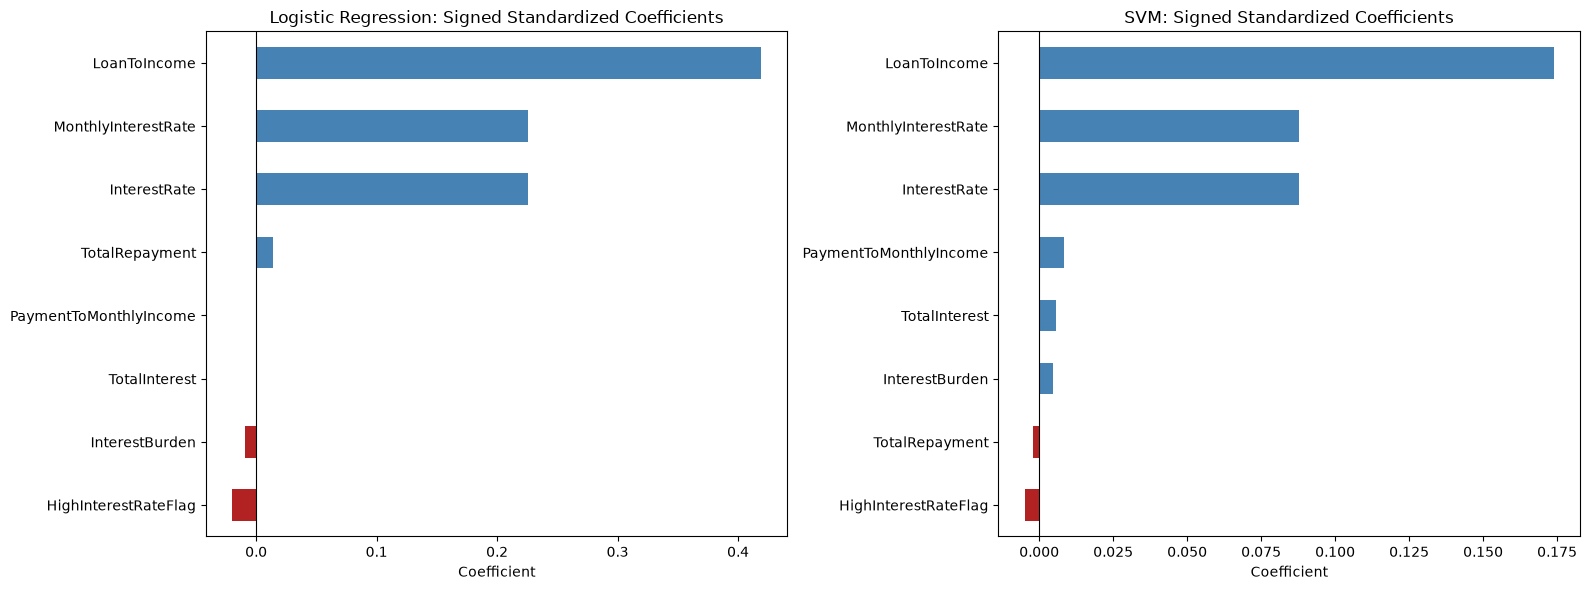

In [58]:
# Confusion matrices
n_models = len(best_models)
n_cols = 4
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = np.array(axes).ravel()

for axis, (model_name, fitted_pipeline) in zip(axes, best_models.items()):
    model_predictions = fitted_pipeline.predict(X_test)
    matrix = confusion_matrix(y_test, model_predictions)

    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["No Default", "Default"]
    ).plot(ax=axis, colorbar=False)

    axis.set_title(model_name)

# Hide any unused subplot axes
for axis in axes[len(best_models):]:
    axis.axis("off")

plt.suptitle("Confusion Matrices", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# Signed standardized coefficients for linear models
linear_model_candidates = ["Logistic Regression", "SVM", "Linear SVC"]

linear_models = [
    name for name in linear_model_candidates
    if name in best_models and hasattr(best_models[name].named_steps["model"], "coef_")
]

if len(linear_models) == 0:
    print("No linear models with coefficients found in best_models.")
else:
    fig, axes = plt.subplots(1, len(linear_models), figsize=(8 * len(linear_models), 6))
    axes = np.atleast_1d(axes)

    for axis, model_name in zip(axes, linear_models):
        fitted_model = best_models[model_name].named_steps["model"]
        coefficients = pd.Series(
            fitted_model.coef_.ravel(),
            index=selected_features
        ).sort_values()

        colors = np.where(coefficients >= 0, "steelblue", "firebrick")
        coefficients.plot(kind="barh", ax=axis, color=colors)

        axis.axvline(0, color="black", linewidth=0.8)
        axis.set_title(f"{model_name}: Signed Standardized Coefficients")
        axis.set_xlabel("Coefficient")

    plt.tight_layout()
    plt.show()

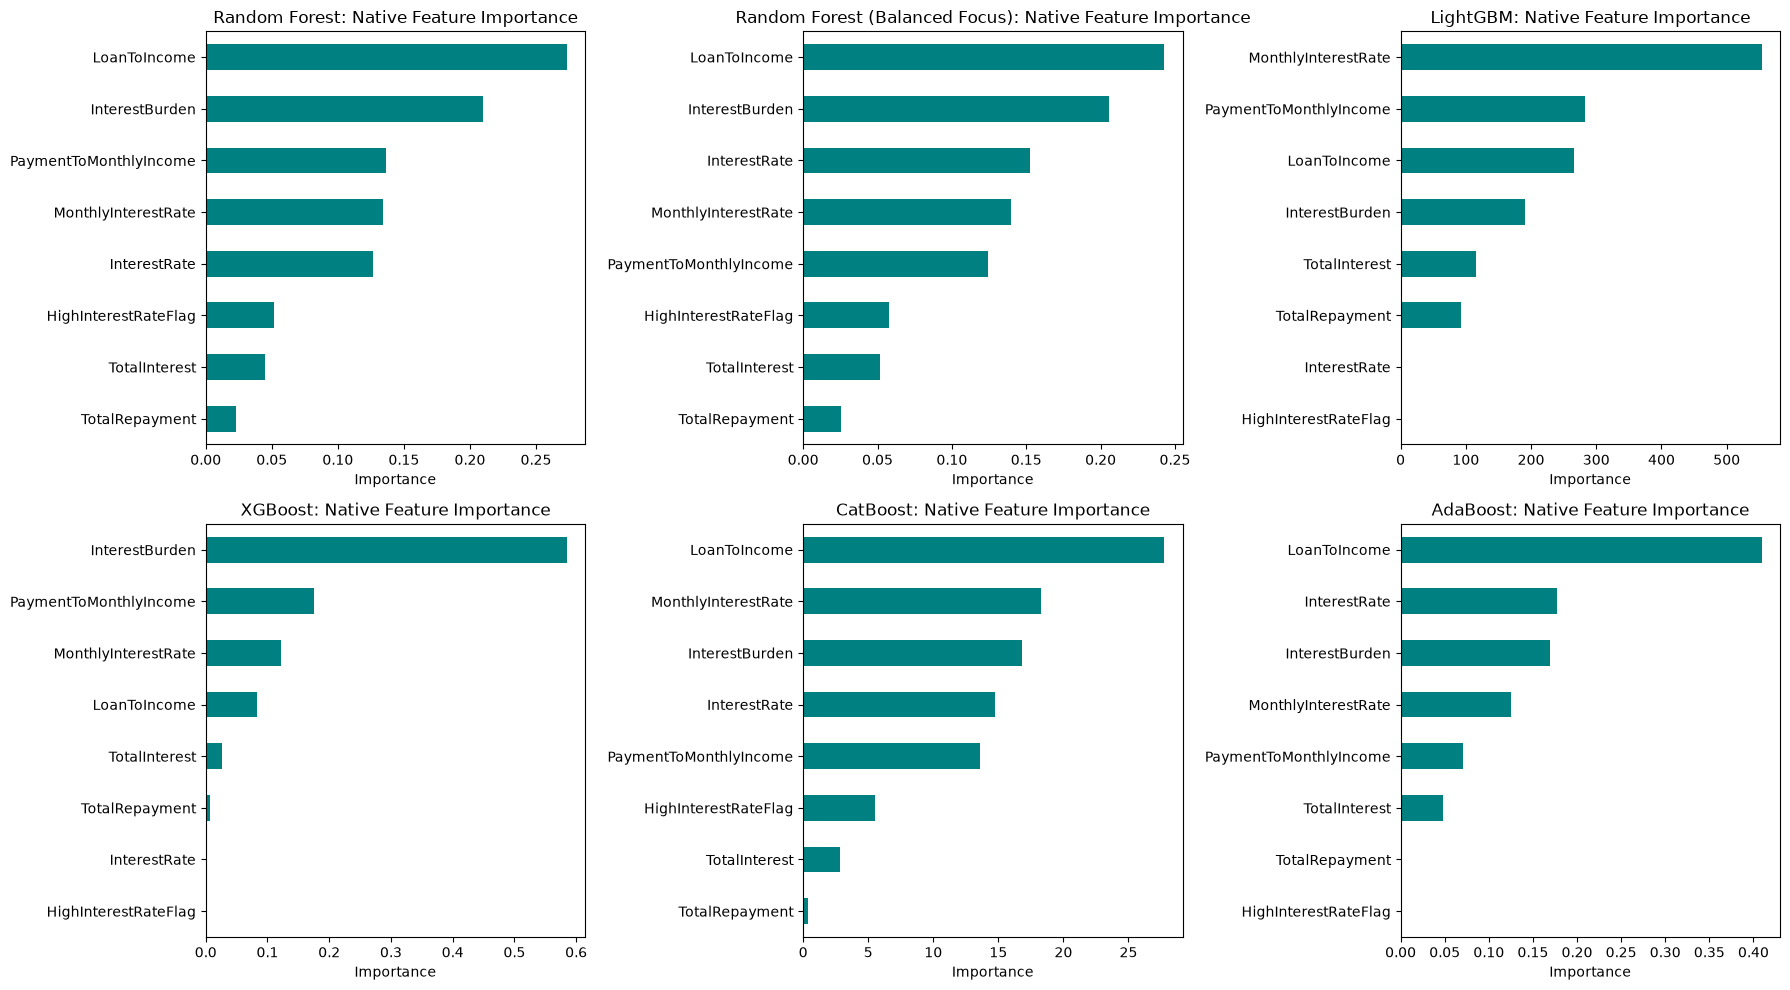

In [59]:
# Native feature importance for tree and boosting models
tree_boost_models = [
    "Random Forest", "Random Forest (Balanced Focus)", "LightGBM",
    "XGBoost", "CatBoost", "AdaBoost"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for axis, model_name in zip(axes, tree_boost_models):
    fitted_model = best_models[model_name].named_steps["model"]

    importance = pd.Series(
        fitted_model.feature_importances_,
        index=selected_features
    ).sort_values()

    importance.plot(kind="barh", ax=axis, color="teal")
    axis.set_title(f"{model_name}: Native Feature Importance")
    axis.set_xlabel("Importance")

plt.tight_layout()
plt.show()

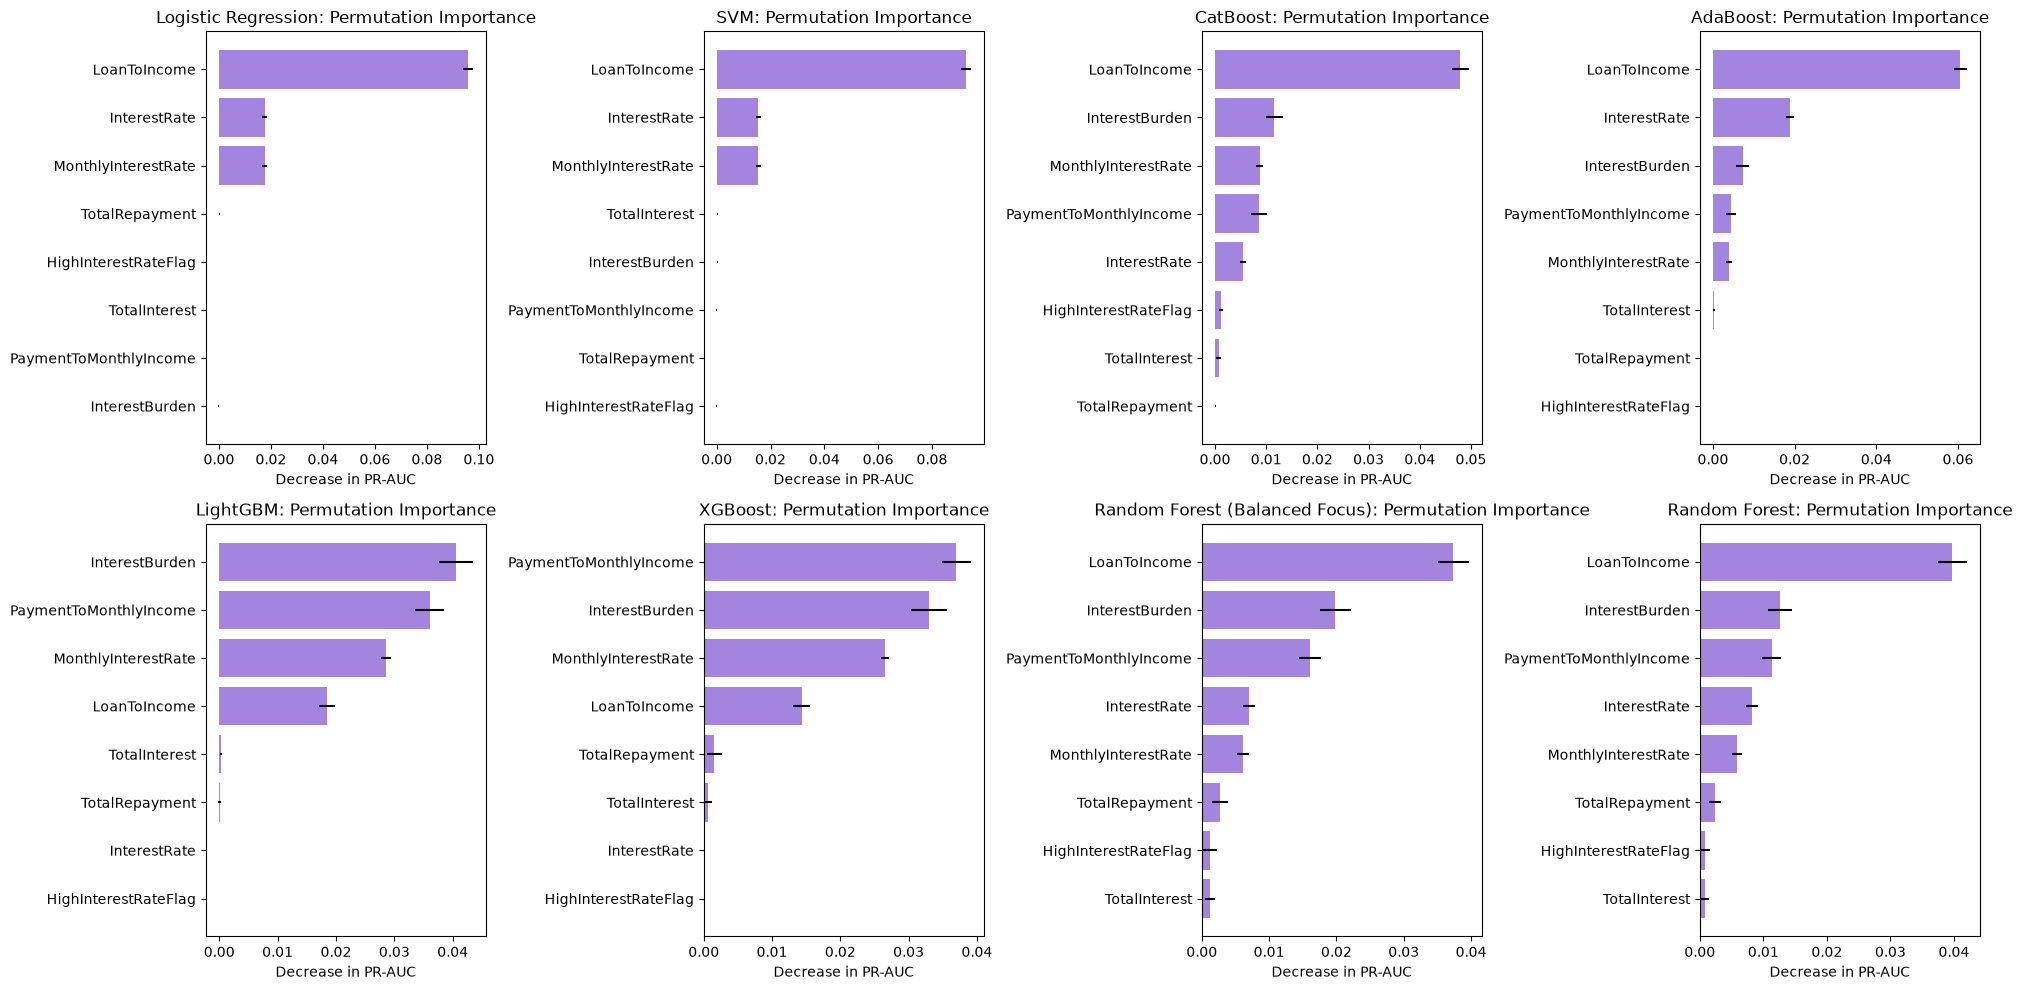


FINAL RANKING — PRIMARY SORT: TEST PR-AUC


,Model,PR-AUC,ROC-AUC,Precision,Recall,F1-Score,Predicted Positive Rate,CV PR-AUC,CV-to-Test PR-AUC Difference
0,SVM,0.241452,0.673626,0.314059,0.193222,0.239248,0.071451,0.237803,-0.003649
1,Logistic Regression,0.241336,0.673643,0.307029,0.204013,0.245138,0.077169,0.237794,-0.003542
2,Random Forest,0.240999,0.671348,0.299495,0.209914,0.246828,0.081398,0.234967,-0.006032
3,Random Forest (Balanced Focus),0.240579,0.671183,0.177847,0.597201,0.274074,0.389975,0.234105,-0.006474
4,CatBoost,0.240271,0.671894,0.306447,0.201147,0.242875,0.076229,0.236208,-0.004063
5,LightGBM,0.239922,0.671217,0.325194,0.184117,0.235117,0.065753,0.235601,-0.004321
6,XGBoost,0.239405,0.670900,0.294666,0.207722,0.243671,0.081868,0.235107,-0.004298
7,AdaBoost,0.238213,0.669914,0.320955,0.183612,0.233591,0.066438,0.234294,-0.003918



Operational interpretation: Precision@k measures the default rate among the highest-risk applicants selected for action, while Recall@k measures the share of all defaults captured. Increasing k generally captures more defaults (higher recall) but lowers precision and lift. Model selection should prioritize PR-AUC and business capacity rather than ROC-AUC alone.


In [60]:
# Permutation importance for every model
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for axis, model_name in zip(axes, best_models):
    importance_data = (
        permutation_importance_df[
            permutation_importance_df["Model"] == model_name
        ]
        .sort_values("Importance Mean")
    )

    axis.barh(
        importance_data["Feature"],
        importance_data["Importance Mean"],
        xerr=importance_data["Importance Std"],
        color="mediumpurple",
        alpha=0.85
    )
    axis.set_title(f"{model_name}: Permutation Importance")
    axis.set_xlabel("Decrease in PR-AUC")

plt.tight_layout()
plt.show()

final_comparison_df = (
    evaluation_df
    .merge(
        model_selection_df[
            ["Model", "CV PR-AUC", "CV-to-Test PR-AUC Difference"]
        ],
        on="Model",
        how="left"
    )
    .sort_values(["PR-AUC", "ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

print("\nFINAL RANKING — PRIMARY SORT: TEST PR-AUC")
display(
    final_comparison_df[
        ["Model", "PR-AUC", "ROC-AUC", "Precision", "Recall",
         "F1-Score", "Predicted Positive Rate",
         "CV PR-AUC", "CV-to-Test PR-AUC Difference"]
    ]
)

print(
    "\nOperational interpretation: Precision@k measures the default rate among "
    "the highest-risk applicants selected for action, while Recall@k measures "
    "the share of all defaults captured. Increasing k generally captures more "
    "defaults (higher recall) but lowers precision and lift. Model selection "
    "should prioritize PR-AUC and business capacity rather than ROC-AUC alone."
)

In [61]:
current_timestamp = pd.Timestamp.now()
print("Current timestamp:", current_timestamp)

Current timestamp: 2026-07-31 20:11:30.711275


In [62]:
best_metrics = results_df.loc[results_df["Test PR-AUC"].idxmax()]
best_model_name = best_metrics["Model"]
best_model = best_models[best_model_name]

safe_timestamp = current_timestamp.strftime("%Y-%m-%d_%H-%M-%S")
model_file = f"best_credit_risk_model_{safe_timestamp}.pkl"

with open(model_file, "wb") as file:
    pickle.dump(best_model, file)

print(f"Saved best model to: {model_file}")
print(f"Model selected by Test PR-AUC: {best_model_name}")
print(f"Best hyperparameters: {best_metrics['Best Hyperparameters']}")
print(f"CV PR-AUC: {best_metrics['CV PR-AUC']:.4f}")
print(f"Test PR-AUC: {best_metrics['Test PR-AUC']:.4f}")
print(f"Test ROC-AUC: {best_metrics['Test ROC-AUC']:.4f}")
print(f"Test precision: {best_metrics['Test Precision']:.4f}")
print(f"Test recall: {best_metrics['Test Recall']:.4f}")
print(f"Test F1-score: {best_metrics['Test F1-Score']:.4f}")

Saved best model to: best_credit_risk_model_2026-07-31_20-11-30.pkl
Model selected by Test PR-AUC: SVM
Best hyperparameters: OrderedDict({'model__C': 0.7099668574083867, 'model__loss': 'squared_hinge', 'model__penalty': 'l2'})
CV PR-AUC: 0.2378
Test PR-AUC: 0.2415
Test ROC-AUC: 0.6736
Test precision: 0.3141
Test recall: 0.1932
Test F1-score: 0.2392
